In [1]:
import xarray as xr

ds = xr.open_dataset("record_breaking_probability_ENSO_removed_lag-1.nc")
print(ds)

/home/users/kastanie/nb_envs/name-of-environment/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


<xarray.Dataset> Size: 12kB
Dimensions:                      (region_id: 237, period: 5)
Coordinates:
  * region_id                    (region_id) int64 2kB 0 1 2 3 ... 234 235 236
  * period                       (period) <U9 180B '1981-1990' ... '2020-2024'
Data variables:
    record_breaking_probability  (region_id, period) float64 9kB ...


ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_identify: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed
ERROR:fiona._env:PROJ: proj_identify: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj faile

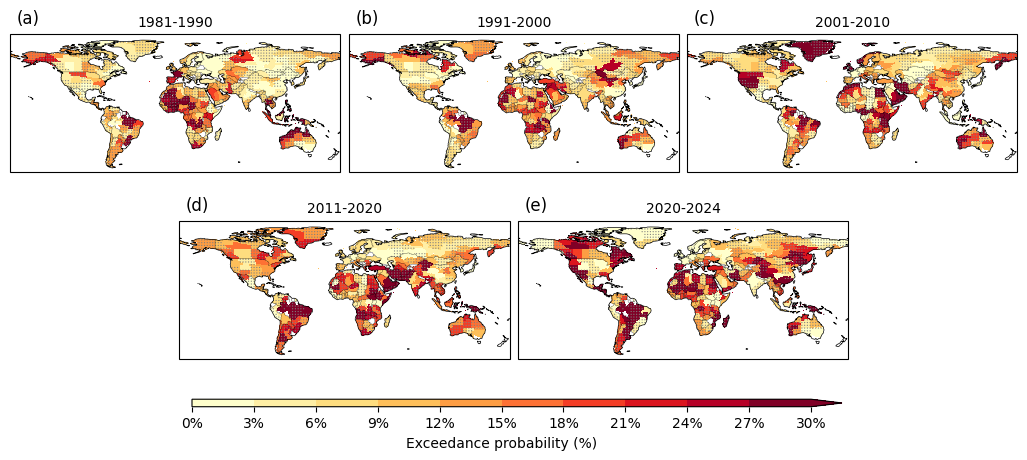

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec

# === 读取数据 ===
prob_ds = xr.open_dataset("record_breaking_probability_ENSO_removed_lag-1.nc")

mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/grid_comparison_fidelity_trend_corrected.nc"
)

# === 提取变量 ===
prob_map = prob_ds["record_breaking_probability"].values  # (region, period)

region_ids = mask_ds['region_id'].values
lat = mask_ds['latitude'].values
lon = mask_ds['longitude'].values

fidelity = fidelity_ds["fidelity_score"]

# === fidelity mask ===
fidelity_mask = fidelity == 3
hatch_mask = (~fidelity_mask.values) & (~np.isnan(region_ids))

n_regions = 237

# === period labels ===
period_labels = prob_ds["period"].values.tolist()


# === 色标 ===
bounds = np.arange(0, 0.301, 0.03)
cmap = plt.get_cmap("YlOrRd", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)


def plot_prob_map(region_data, title, ax, dot_size=0.8, dot_color='grey'):
    # === region → grid ===
    map_data = np.full_like(region_ids, np.nan, dtype=np.float64)
    for r in range(n_regions):
        map_data[region_ids == r] = region_data[r]

    masked_data = np.ma.masked_invalid(map_data)

    # === 主图 ===
    im = ax.pcolormesh(
        lon, lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # === 低保真点 ===
    low_fid_mask = hatch_mask
    lons_dot, lats_dot = np.meshgrid(lon, lat)

    rows, cols = np.where(low_fid_mask)

    row_step = 3
    col_step = 3

    mask_sparse = (rows % row_step == 0) & (cols % col_step == 0)

    rows_sparse = rows[mask_sparse]
    cols_sparse = cols[mask_sparse]

    lons_dot = lons_dot[rows_sparse, cols_sparse]
    lats_dot = lats_dot[rows_sparse, cols_sparse]

    ax.scatter(
        lons_dot, lats_dot,
        s=dot_size,
        c=dot_color,
        marker='o',
        edgecolors='none',
        transform=ccrs.PlateCarree(),
        alpha=1
    )

    # === 地图设置 ===
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax.set_title(title, fontsize=10)

    return im


def plot_gev_probability_grid(prob_map, fig_title):

    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(2, 6, figure=fig, height_ratios=[1, 0.9])

    ax_a = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree())
    ax_b = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree())
    ax_c = fig.add_subplot(gs[0, 4:6], projection=ccrs.PlateCarree())
    ax_d = fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree())
    ax_e = fig.add_subplot(gs[1, 3:5], projection=ccrs.PlateCarree())

    axs = [ax_a, ax_b, ax_c, ax_d, ax_e]
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

    for i, ax in enumerate(axs):
        title = period_labels[i]   # ✅ 直接用 nc 里的 period
        data = prob_map[:, i]

        im = plot_prob_map(data, title, ax)

        ax.text(
            0.02, 1.05, labels[i],
            transform=ax.transAxes,
            fontsize=12,
            ha='left',
            va='bottom'
        )

    fig.subplots_adjust(wspace=0.05, hspace=0.02, top=0.92, bottom=0.18)

    cbar_ax = fig.add_axes([0.265, 0.12, 0.5, 0.015])

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        orientation='horizontal',
        ticks=bounds,
        extend='max'
    )

    formatter = FuncFormatter(lambda x, _: f"{x*100:.0f}%")
    cbar.ax.set_xticklabels([formatter(t) for t in bounds])
    cbar.set_label("Exceedance probability (%)")

    plt.savefig(
        "Fig2_record_breaking_probability_ENSO_removed_lag-1.png",
        dpi=800,
        bbox_inches='tight'
    )

    plt.show()


# === 执行 ===
plot_gev_probability_grid(
    prob_map,
    "Probability of record-breaking events (ENSO removed, lag -1)"
)

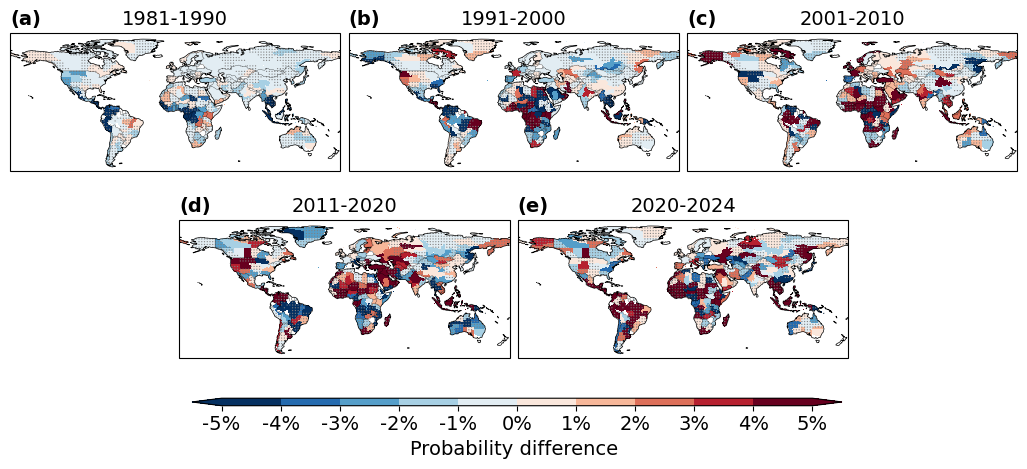

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec

# =========================================================
# === 读取数据
# =========================================================
enso_ds = xr.open_dataset("record_breaking_probability_removed_ENSO_each_ensemble_from_IFS_and_ENSO_obs_from_obs.nc")
raw_ds = xr.open_dataset("record_breaking_probability_raw.nc")

mask_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/region_mask_1deg.nc"
)

fidelity_ds = xr.open_dataset(
    "/home/users/kastanie/Global_regional_analysis/atmos-WRAF01-v4-1/hottestmonth/grid_comparison_fidelity_trend_corrected.nc"
)

# =========================================================
# === 提取变量
# =========================================================
prob_enso = enso_ds["record_breaking_probability"].values
prob_raw = raw_ds["record_breaking_probability"].values

# === difference（核心）===
diff_map = prob_enso - prob_raw   # (region, period)

region_ids = mask_ds['region_id'].values
lat = mask_ds['latitude'].values
lon = mask_ds['longitude'].values

fidelity = fidelity_ds["fidelity_score"]

# fidelity mask
fidelity_mask = fidelity == 3
hatch_mask = (~fidelity_mask.values) & (~np.isnan(region_ids))

n_regions = 237

# period labels
period_labels = enso_ds["period"].values.tolist()

# =========================================================
# === 色标（difference 专用）
# =========================================================
bounds = np.arange(-0.05, 0.051, 0.01)   # -5% 到 5%
cmap = plt.get_cmap("RdBu_r", len(bounds) - 1)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)


# =========================================================
# === 绘图函数
# =========================================================
def plot_prob_map(region_data, title, ax, dot_size=0.8, dot_color='grey'):

    map_data = np.full_like(region_ids, np.nan, dtype=np.float64)
    for r in range(n_regions):
        map_data[region_ids == r] = region_data[r]

    masked_data = np.ma.masked_invalid(map_data)

    im = ax.pcolormesh(
        lon, lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )

    # === 低保真点 ===
    low_fid_mask = hatch_mask
    lons_dot, lats_dot = np.meshgrid(lon, lat)

    rows, cols = np.where(low_fid_mask)

    row_step = 3
    col_step = 3

    mask_sparse = (rows % row_step == 0) & (cols % col_step == 0)

    rows_sparse = rows[mask_sparse]
    cols_sparse = cols[mask_sparse]

    lons_dot = lons_dot[rows_sparse, cols_sparse]
    lats_dot = lats_dot[rows_sparse, cols_sparse]

    ax.scatter(
        lons_dot, lats_dot,
        s=dot_size,
        c=dot_color,
        marker='o',
        edgecolors='none',
        transform=ccrs.PlateCarree(),
        alpha=1
    )

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)
    ax.set_title(title, fontsize=14)

    return im


# =========================================================
# === 主图函数
# =========================================================
def plot_difference_grid(diff_map, fig_title):

    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(2, 6, figure=fig, height_ratios=[1, 0.9])

    ax_a = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree())
    ax_b = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree())
    ax_c = fig.add_subplot(gs[0, 4:6], projection=ccrs.PlateCarree())
    ax_d = fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree())
    ax_e = fig.add_subplot(gs[1, 3:5], projection=ccrs.PlateCarree())

    axs = [ax_a, ax_b, ax_c, ax_d, ax_e]
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)']

    for i, ax in enumerate(axs):
        title = period_labels[i]
        data = diff_map[:, i]

        im = plot_prob_map(data, title, ax)

        ax.text(
            0.00, 1.03, labels[i],
            transform=ax.transAxes,
            fontsize=14,
            ha='left',
            va='bottom',
            fontweight='bold'
        )

    fig.subplots_adjust(wspace=0.05, hspace=0.02, top=0.92, bottom=0.18)

    # === colorbar ===
    cbar_ax = fig.add_axes([0.265, 0.12, 0.5, 0.015])

    cbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax,
        orientation='horizontal',
        ticks=bounds,
        extend='both'
    )

    formatter = FuncFormatter(lambda x, _: f"{x*100:.0f}%")
    cbar.ax.set_xticklabels([formatter(t) for t in bounds])
    cbar.set_label("Probability difference ",fontsize=14)
    cbar.ax.tick_params(labelsize=14)

    plt.savefig(
        "FigS6_difference_ENSO_removed_both.pdf",
        dpi=400,
        bbox_inches='tight'
    )

    plt.show()


# =========================================================
# === 执行
# =========================================================
plot_difference_grid(
    diff_map,
    "Difference (ENSO removed - raw)"
)